<a href="https://colab.research.google.com/github/MSaadT313/NLP-SummerCamp-CRAAT/blob/main/DAY_4_BERT_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using device: cuda

Loading dataset...
Initializing model and tokenizer...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Extracting Pre-Finetuning Embeddings...


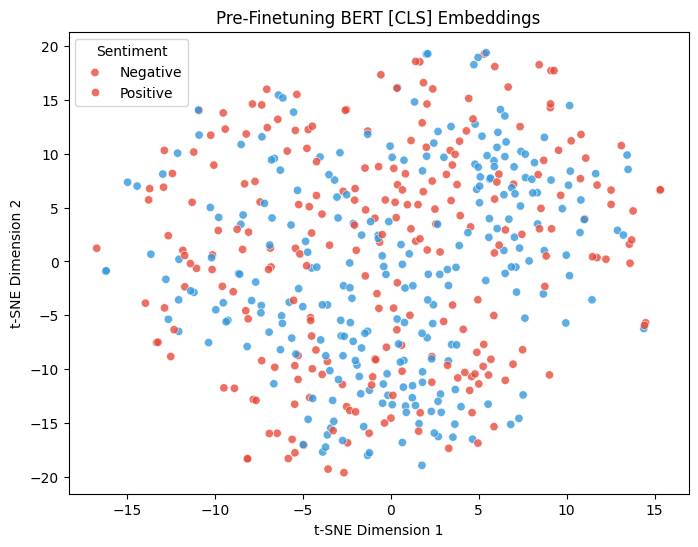


Tokenizing dataset for fine-tuning...


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score

# Run this installation command in your notebook cell first, or remove the '!' to run in a terminal:
!pip install -q transformers datasets torch scikit-learn matplotlib seaborn

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# 2. Load Dataset (IMDB from CSV - binary sentiment)
print("Loading dataset...")

# Load the IMDB CSV file directly using load_dataset
# The `load_dataset` function with a CSV file typically returns a DatasetDict,
# with a 'train' split if only one file is provided.
raw_dataset = load_dataset("csv", data_files="/content/drive/MyDrive/Corpus Data/imdb_dataset/train.csv")

# To access the actual Dataset object, we need to specify the split, e.g., 'train'.
# The CSV columns are likely 'review' and 'sentiment'. Rename them to 'text' and 'label'
# to match the rest of the code's expectations for general NLP tasks.
processed_raw_dataset_train = raw_dataset["train"].rename_column("review", "text").rename_column("sentiment", "label")

viz_dataset = processed_raw_dataset_train.shuffle(seed=42).select(range(500))
texts = viz_dataset["text"] # Now 'text' column for reviews should exist
labels = viz_dataset["label"] # Now 'label' column for sentiment should exist

# 3. Initialize Model and Tokenizer
print("Initializing model and tokenizer...")
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Enable output_hidden_states=True to intercept embeddings
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    output_hidden_states=True
).to(device)

# 4. Helper Functions for Embeddings and Visualization
def extract_embeddings(model, tokenizer, texts, batch_size=16):
    """Passes text through the model and extracts the final [CLS] token embedding."""
    model.eval()
    embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(
                batch_texts, padding=True, truncation=True,
                return_tensors="pt", max_length=128
            ).to(device)

            outputs = model(**inputs)
            # Grab the [CLS] token from the final hidden layer
            cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

    return np.vstack(embeddings)

def plot_tsne(embeddings, labels, title):
    """Reduces 768-dimensional embeddings to 2D using t-SNE and plots them."""
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_results = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=tsne_results[:, 0], y=tsne_results[:, 1],
        hue=labels, palette=["#e74c3c", "#3498db"], alpha=0.8
    )
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Sentiment", labels=["Negative", "Positive"])
    plt.show()

# 5. Pre-Finetuning Visualization
print("\nExtracting Pre-Finetuning Embeddings...")
pre_embeddings = extract_embeddings(model, tokenizer, texts)
plot_tsne(pre_embeddings, labels, "Pre-Finetuning BERT [CLS] Embeddings")

# 6. Prepare for Fine-Tuning
print("\nTokenizing dataset for fine-tuning...")
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Use the 'train' split of the raw_dataset for tokenization and ensure columns are renamed
tokenized_datasets = processed_raw_dataset_train.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Bypass the torchvision bug
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

tokenized_datasets.set_format("torch")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

# Subsample for speed (using 2,000 for train, 500 for eval)
train_subset = tokenized_datasets.shuffle(seed=42).select(range(2000))
eval_subset = tokenized_datasets.shuffle(seed=42).select(range(500))


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Starting Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.390128,0.247694,0.914000,0.915187
2,0.231984,0.167485,0.938000,0.937374


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating on evaluation subset...


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.231984,0.167485,2,0.938000,0.937374


Test Accuracy: 0.9380
Test F1 Score: 0.9374

Extracting Post-Finetuning Embeddings...


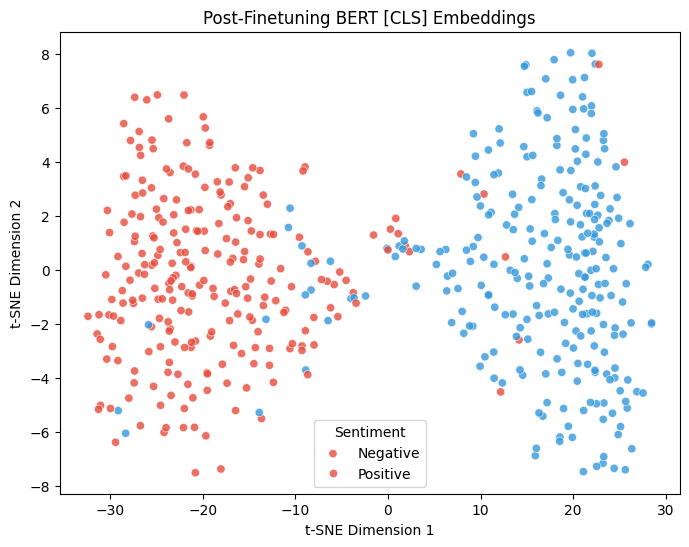

In [14]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Because we set output_hidden_states=True, 'logits' is actually a tuple:
    # (actual_logits, hidden_states). We only need the first part.
    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

# Map 'positive' and 'negative' string labels to integers (0 and 1)
def map_labels_to_int(example):
    if example["labels"] == "positive":
        example["labels"] = 1
    elif example["labels"] == "negative":
        example["labels"] = 0
    return example

# Apply the label mapping to the subsets
train_subset = train_subset.map(map_labels_to_int)
eval_subset = eval_subset.map(map_labels_to_int)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch",
    logging_steps=50,
    report_to="none" # Disables wandb/tensorboard logging prompts in notebooks
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=eval_subset,
    compute_metrics=compute_metrics,
)

# 7. Execute Fine-Tuning
print("\nStarting Fine-Tuning...")
trainer.train()

# 8. Evaluate Efficacy and Post-Finetuning Visualization
print("\nEvaluating on evaluation subset...")
metrics = trainer.evaluate(eval_subset) # Changed from tokenized_datasets["test"] to eval_subset
print(f"Test Accuracy: {metrics['eval_accuracy']:.4f}")
print(f"Test F1 Score: {metrics['eval_f1']:.4f}")

print("\nExtracting Post-Finetuning Embeddings...")
post_embeddings = extract_embeddings(model, tokenizer, texts)
plot_tsne(post_embeddings, labels, "Post-Finetuning BERT [CLS] Embeddings")
